In [1]:
import pandas as pd

In [2]:
path_to_data = '../mimic-iv_data/hosp'
    
dfd = pd.read_csv(f'{path_to_data}/diagnoses_icd.csv')
# HADM IDs are not sorted numerically, need to sort by admission time
dfa = pd.read_csv(f'{path_to_data}/admissions.csv')

# Merge relevant columns from all datasets
dfd = dfd.drop('icd_version', axis=1)
dfa = dfa[['subject_id', 'hadm_id', 'admittime']]
df = pd.merge(dfd, dfa, how='inner')
df['admittime'] = pd.to_datetime(df['admittime'])

# Ensure sorted and keep relevant columns
df = df.sort_values(by=['subject_id', 'admittime', 'seq_num'], ascending=True)
# df = df[['subject_id', 'icd_code']]

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
df[:50]

,subject_id,hadm_id,seq_num,icd_code,admittime
0,10000032,22595853,1,5723,2180-05-06 22:23:00
1,10000032,22595853,2,78959,2180-05-06 22:23:00
2,10000032,22595853,3,5715,2180-05-06 22:23:00
3,10000032,22595853,4,07070,2180-05-06 22:23:00
4,10000032,22595853,5,496,2180-05-06 22:23:00
5,10000032,22595853,6,29680,2180-05-06 22:23:00
6,10000032,22595853,7,30981,2180-05-06 22:23:00
7,10000032,22595853,8,V1582,2180-05-06 22:23:00
8,10000032,22841357,1,07071,2180-06-26 18:27:00
9,10000032,22841357,2,78959,2180-06-26 18:27:00


In [ ]:
res = {}
for item in df[['subject_id', 'hadm_id']].values.tolist():
    res.setdefault(item[0], []).append(item[1])
for k in res:
    res[k] = list(dict.fromkeys(res[k]))

In [ ]:
res

{10000032: [22595853, 22841357, 29079034, 25742920],
 10000068: [25022803],
 10000084: [23052089, 29888819],
 10000108: [27250926],
 10000117: [22927623, 27988844],
 10000248: [20600184],
 10000280: [25852320],
 10000560: [28979390],
 10000635: [26134563],
 10000719: [24558333],
 10000724: [20823482],
 10000764: [27897940],
 10000826: [20032235, 21086876, 28289260],
 10000883: [29957930, 25221576],
 10000886: [21927847],
 10000904: [28328117],
 10000935: [29541074, 24955974, 21738619, 26381316, 25849114],
 10000980: [29654838,
  26913865,
  24947999,
  25242409,
  25911675,
  29659838,
  20897796],
 10001176: [23334588],
 10001180: [21102262, 25534937, 27864856],
 10001186: [24906418, 24016413, 21334040],
 10001217: [24597018, 27703517],
 10001319: [29230609, 23005466, 24591241],
 10001338: [22119639, 28835314, 29335220, 27987619],
 10001401: [21544441, 26840593, 24818636, 27060146, 28058085, 27012892],
 10001472: [23506139],
 10001492: [27463908],
 10001663: [23405714],
 10001667: [22

In [ ]:
d = {hadm_id: i for v in res.values() for i, hadm_id in enumerate(v, start=1) }

In [ ]:
d

{22595853: 1,
 22841357: 2,
 29079034: 3,
 25742920: 4,
 25022803: 1,
 23052089: 1,
 29888819: 2,
 27250926: 1,
 22927623: 1,
 27988844: 2,
 20600184: 1,
 25852320: 1,
 28979390: 1,
 26134563: 1,
 24558333: 1,
 20823482: 1,
 27897940: 1,
 20032235: 1,
 21086876: 2,
 28289260: 3,
 29957930: 1,
 25221576: 2,
 21927847: 1,
 28328117: 1,
 29541074: 1,
 24955974: 2,
 21738619: 3,
 26381316: 4,
 25849114: 5,
 29654838: 1,
 26913865: 2,
 24947999: 3,
 25242409: 4,
 25911675: 5,
 29659838: 6,
 20897796: 7,
 23334588: 1,
 21102262: 1,
 25534937: 2,
 27864856: 3,
 24906418: 1,
 24016413: 2,
 21334040: 3,
 24597018: 1,
 27703517: 2,
 29230609: 1,
 23005466: 2,
 24591241: 3,
 22119639: 1,
 28835314: 2,
 29335220: 3,
 27987619: 4,
 21544441: 1,
 26840593: 2,
 24818636: 3,
 27060146: 4,
 28058085: 5,
 27012892: 6,
 23506139: 1,
 27463908: 1,
 23405714: 1,
 22672901: 1,
 25563031: 1,
 21728396: 1,
 21441082: 1,
 25679292: 1,
 21320596: 2,
 21268656: 1,
 26679629: 2,
 23594368: 3,
 21577720: 4,
 24325

In [ ]:
dfv = pd.DataFrame({'hadm_id': list(d.keys()), 'visit_order': list(d.values())})

In [ ]:
dfv[dfv['hadm_id']==22595853]

,hadm_id,visit_order
0,22595853,1


In [ ]:
df = pd.merge(df, dfv)

In [ ]:
df[:50]

,subject_id,hadm_id,seq_num,icd_code,admittime,visit_order
0,10000032,22595853,1,5723,2180-05-06 22:23:00,1
1,10000032,22595853,2,78959,2180-05-06 22:23:00,1
2,10000032,22595853,3,5715,2180-05-06 22:23:00,1
3,10000032,22595853,4,07070,2180-05-06 22:23:00,1
4,10000032,22595853,5,496,2180-05-06 22:23:00,1
5,10000032,22595853,6,29680,2180-05-06 22:23:00,1
6,10000032,22595853,7,30981,2180-05-06 22:23:00,1
7,10000032,22595853,8,V1582,2180-05-06 22:23:00,1
8,10000032,22841357,1,07071,2180-06-26 18:27:00,2
9,10000032,22841357,2,78959,2180-06-26 18:27:00,2


In [ ]:
df = df[['subject_id', 'visit_order', 'seq_num', 'icd_code']]

In [ ]:
df

,subject_id,visit_order,seq_num,icd_code
0,10000032,1,1,5723
1,10000032,1,2,78959
2,10000032,1,3,5715
3,10000032,1,4,07070
4,10000032,1,5,496
...,...,...,...,...
5006879,19999987,1,7,41401
5006880,19999987,1,8,78039
5006881,19999987,1,9,0413
5006882,19999987,1,10,36846


In [ ]:
from tqdm import tqdm

In [ ]:
# Turn df into mapping
dataset_dict = {}
for _, row in tqdm(df.iterrows()):
    for k in ['icd_code', 'visit_order', 'seq_num']:
        dataset_dict.setdefault(row['subject_id'], {}).setdefault(k, []).append(row[k])

5006884it [07:23, 11293.97it/s]


In [ ]:
# import pickle
# with open('./data/mimic_icd_data_dict.pkl', 'wb') as f:
#     pickle.dump(dataset_dict, f)

## Make a hf dataset

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer
import pickle

tokenizer = AutoTokenizer.from_pretrained('/root/data/tokenizer-icd-final')

with open('/root/data/mimic-iv_data/mimic_icd_data_dict.pkl', 'rb') as f:
    datadict = pickle.load(f)

tokenization_params = {
    'max_length': 128,
    'truncation': True,
    'padding': 'max_length',
    'is_split_into_words': True,
    'return_special_tokens_mask': True
}

In [ ]:
dd = {}
for d in datadict.values():
    for k, v in d.items():
        dd.setdefault(k, []).append(v)

In [ ]:
import datasets
ds = Dataset.from_dict(dd)

In [ ]:
def process_function(entry, tokenization_params):
    codes = entry['icd_code']
    # Get coding embedding ids
    encoding = tokenizer(codes, **tokenization_params)
    # Add token type ids for visit sequence
    num_codes_to_keep = min(tokenization_params['max_length'] - 2, len(codes))
    encoding['token_type_ids'][1:num_codes_to_keep+1] = entry['visit_order'][:num_codes_to_keep]
    entry.update(encoding)
    return entry
ds = ds.map(lambda x: process_function(x, tokenization_params), num_proc=4, remove_columns=['icd_code', 'visit_order', 'seq_num'])

#0:   0%|          | 0/47545 [00:00<?, ?ex/s]

#1:   0%|          | 0/47545 [00:00<?, ?ex/s]

#2:   0%|          | 0/47545 [00:00<?, ?ex/s]

#3:   0%|          | 0/47544 [00:00<?, ?ex/s]

In [ ]:
ds

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'special_tokens_mask'],
    num_rows: 190179
})

In [ ]:
ds.save_to_disk('/root/data/mimic-iv_data/mimic_icd_hf_dataset')

## PyTorch dataset

In [ ]:
from torch.utils.data import Dataset
import torch

In [ ]:
class MimicIcdDataset(Dataset):
    def __init__(self, data_dict, tokenizer, tokenization_params, max_token_type_ids=100):
        """
        Setup parameters for the dataset
        Parameters
        ----------
        data_dict : dict with keys as patient ids
            training/validation data
        tokenizer : transformers tokenizer
            Tokenizer to do encoding of text
        tokenization_params : dict
            Parameters for tokenization passed to tokenizer. Note, do not set {'return_tensors': 'pt'} because this adds
            an extra dimension. Keep 'return_tensors' to default as this function does the torch tensor conversion when
            it returns the item.
            Suggested parameters: {'max_length': 512, 'truncation': True, 'padding': 'max_length'}
        """
        super().__init__()
        self.data = data_dict
        self.tokenizer = tokenizer
        self.params = tokenization_params
        self.patients = list(self.data.keys())
        self.len = len(self.data)
        self.max_token_type_ids = max_token_type_ids

    def __len__(self):
        return self.len

    def __getitem__(self, index):
        """Processing when returning an item from the Dataset. Converts text into encoding using tokenizer.
        Converts items from encoding to PyTorch tensors
        Parameters
        ----------
        index : int
            index of item to access
        Returns
        -------
        dict
            Output encoding from the tokenizer on the text.
            Relevant keys are ['input_ids', 'attention_mask', 'token_type_ids', 'label']
            What keys are present may depend on tokenizer parameters
        """
        k = self.patients[index]
        data = self.data[k]
        codes = data['icd_code']
        # Get coding embedding ids
        encoding = self.tokenizer(codes, **self.params)
        # Add token type ids for visit sequence
        num_codes_to_keep = min(self.params['max_length'] - 2, len(codes))
        encoding['token_type_ids'][1:num_codes_to_keep+1] = data['visit_order'][:num_codes_to_keep]
        encoding = {key: torch.as_tensor(val) for key, val in encoding.items()}
        return encoding


In [ ]:
tokenization_params = {
    'max_length': 128,
    'truncation': True,
    'padding': 'max_length',
    'is_split_into_words': True,
    'return_special_tokens_mask': True
}

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('./data/tokenizer-icd-final')

In [ ]:
ds = MimicIcdDataset(dataset_dict, tokenizer, tokenization_params)

In [ ]:
ds[0]

{'input_ids': tensor([    1,  3819,  5993,  3812,   267,  3383,  1685,  1890, 23920,   268,
          5993,  1525,  1386,  3383,  3812, 23739,  1808,  3217,   260,  6107,
          1386,  5993,  1396,  1808, 23739, 24249, 24183,  3383,  1685,  3812,
           265,  5993, 24183,  3812,  1396,  1386,  3383, 23739,  1808,  5940,
             2,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,   

In [ ]:
from transformers import DataCollatorForLanguageModeling
from torch.utils.data import DataLoader

BATCH_SIZE = 64

dataloader = DataLoader(ds, shuffle=True, batch_size=BATCH_SIZE,
    collate_fn=DataCollatorForLanguageModeling(tokenizer),
    num_workers=4, pin_memory=True)

In [ ]:
iter_loader = iter(dataloader)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [ ]:
batch = next(iter_loader)

In [ ]:
batch['input_ids'].shape

torch.Size([64, 128])

In [ ]:
batch['labels']

tensor([[ -100,  -100,  -100,  ...,  -100,  -100,  -100],
        [ -100,  -100,  -100,  ...,  -100,  -100,  -100],
        [ -100, 14309,  -100,  ...,  -100,  -100,  -100],
        ...,
        [ -100,  -100,   380,  ...,  -100,  -100,  -100],
        [ -100,  -100,  -100,  ...,  -100,  -100,  -100],
        [ -100,  -100,  -100,  ...,  -100,  -100,  -100]])

# Look at the distribution of codes

In [3]:
import pickle
with open('./data/mimic_icd_data_dict.pkl', 'rb') as f:
    datadict = pickle.load(f)

In [4]:
datadict[10000032]

{'icd_code': ['5723',
  '78959',
  '5715',
  '07070',
  '496',
  '29680',
  '30981',
  'V1582',
  '07071',
  '78959',
  '2875',
  '2761',
  '496',
  '5715',
  'V08',
  '3051',
  '45829',
  '07044',
  '7994',
  '2761',
  '78959',
  '2767',
  '3051',
  'V08',
  'V4986',
  'V462',
  '496',
  '29680',
  '5715',
  '07054',
  '78959',
  'V462',
  '5715',
  '2767',
  '2761',
  '496',
  'V08',
  '3051',
  '78791'],
 'visit_order': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4],
 'seq_num': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10]}

In [5]:
from collections import Counter
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
c = Counter()

for pid, data in tqdm(datadict.items()):
    c.update(data['icd_code'])

100%|██████████| 190179/190179 [00:01<00:00, 178466.35it/s]


In [7]:
dist = c.most_common()

In [8]:
dist[0][1] / sum(c.values())

0.020476008631316402

In [9]:
codes, freq = list(zip(*dist))

In [10]:
freq = np.array(freq)

In [11]:
df = pd.read_csv('../mimic-iv_data/hosp/d_icd_diagnoses.csv')

In [12]:
icd_lut = {k: v for k, v in zip(df['icd_code'].tolist(), df['long_title'].tolist())}

In [13]:
codes = [f"{k}: {icd_lut[k]}" for k in codes]

In [14]:
codes

['4019: Unspecified essential hypertension',
 '2724: Other and unspecified hyperlipidemia',
 'I10: Essential (primary) hypertension',
 'E785: Hyperlipidemia, unspecified',
 '53081: Esophageal reflux',
 '25000: Diabetes mellitus without mention of complication, type II or unspecified type, not stated as uncontrolled',
 'Z87891: Personal history of nicotine dependence',
 '42731: Atrial fibrillation',
 '4280: Congestive heart failure, unspecified',
 '311: Depressive disorder, not elsewhere classified',
 '41401: Coronary atherosclerosis of native coronary artery',
 'K219: Gastro-esophageal reflux disease without esophagitis',
 'V1582: Personal history of tobacco use',
 'F329: Major depressive disorder, single episode, unspecified',
 '5849: Acute kidney failure, unspecified',
 '2449: Unspecified acquired hypothyroidism',
 'I2510: Atherosclerotic heart disease of native coronary artery without angina pectoris',
 '3051: Tobacco use disorder',
 '2859: Anemia, unspecified',
 'F419: Anxiety diso

Text(0, 0.5, 'prob')

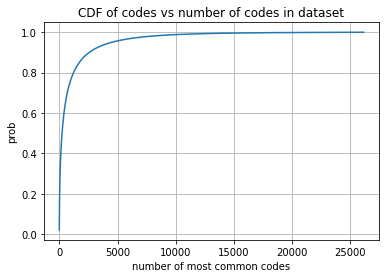

In [15]:
# Plot cdf

cdf = np.cumsum(freq / sum(c.values()))
plt.plot(cdf)
plt.grid('on')
plt.title('CDF of codes vs number of codes in dataset')
plt.xlabel('number of most common codes')
plt.ylabel('prob')

In [16]:
cdf[cdf < .31].shape

(71,)